# CD4T / Treg / DNT atlas: label cells of interest and find marker genes

1. Load `human_immune_health_atlas_cd4t-treg-dnt.h5ad` with scanpy
2. Label the cells whose barcodes are in a supplied list as the cell type of interest (everything else -> `"other"`)
3. Run a Wilcoxon rank-sum test (`sc.tl.rank_genes_groups`, `method="wilcoxon"`) to find the top marker genes for that group vs. the rest
4. Inspect and save the marker gene table

In [45]:
import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

sc.settings.verbosity = 1
%matplotlib inline

## Parameters

Edit these paths/values for your run.

In [2]:
# Path to the atlas
H5AD_PATH = "human_immune_health_atlas_cd4t-treg-dnt.h5ad"

# Path to the file listing barcodes of the cell type of interest.
# Accepts either a plain text file with one barcode per line, or a CSV
# whose first column contains the barcodes.
BARCODE_LIST_PATH = "selected_barcodes.csv"

# Label to assign to the cells matching BARCODE_LIST_PATH
CELL_TYPE_LABEL = "cell_type_of_interest"

# Name of the obs column that will hold the cell_type_of_interest / other labels
GROUP_COLUMN = "group"

# Whether to run sc.pp.normalize_total + sc.pp.log1p before the DE test.
# Set to False if adata.X is already normalized/log-transformed (check the
# diagnostic cell below before deciding).
NORMALIZE_DATA = False

# Fraction of "other" (non-selected) cells to randomly subsample as the
# reference/control group for the Wilcoxon test, instead of using all of them.
# Keeps the DE test fast on a large atlas while still comparing against a
# representative background.
OTHER_CELLS_FRACTION = 0.05
RANDOM_SEED = 0

# How many top marker genes to report/plot
TOP_N_GENES = 25

OUTPUT_DIR = Path("results")
OUTPUT_DIR.mkdir(exist_ok=True)

## Load the atlas

In [3]:
adata = sc.read_h5ad(H5AD_PATH)
adata

AnnData object with n_obs × n_vars = 743615 × 33538
    obs: 'cohort.cohortGuid', 'sample.sampleKitGuid', 'specimen.specimenGuid', 'pipeline.fileGuid', 'subject.subjectGuid', 'subject.biologicalSex', 'subject.birthYear', 'subject.ageAtFirstDraw', 'subject.ageGroup', 'subject.race', 'subject.ethnicity', 'subject.cmv', 'subject.bmi', 'sample.visitName', 'sample.drawYear', 'sample.subjectAgeAtDraw', 'batch_id', 'pool_id', 'chip_id', 'well_id', 'barcodes', 'original_barcodes', 'cell_name', 'n_reads', 'n_umis', 'n_genes', 'total_counts_mito', 'pct_counts_mito', 'doublet_score', 'AIFI_L1', 'AIFI_L2', 'AIFI_L3'
    var: 'mito', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'
    uns: 'AIFI_L1_colors', 'AIFI_L2_colors', 'AIFI_L3_colors', 'celltypist.low_colors', 'hvg', 'keep_colors', 'leiden', 'leiden_colors', 'log1p', 'neighbors', 'pca', 'seurat.l2.5_colors', 'umap'
    obsm: 'X_pca', 'X_pca_harmony', 'X_umap'
    obsp: 'c

In [4]:
# Diagnostic: helps decide whether NORMALIZE_DATA above should be True or False.
# Raw counts are non-negative integers with a large max; normalized/log data
# is typically float with a small max (~10 or less).
print("X dtype:", adata.X.dtype)
print("X min/max:", adata.X.min(), adata.X.max())
print("layers:", list(adata.layers.keys()))

X dtype: float32
X min/max: 0.0 8.728732
layers: [None]


## Load perturbations of interest

In [23]:
df_selected_perturbations = pd.read_csv("selected_perturbations.csv")

## Label cells of interest from the barcode list

In [5]:
barcode_path = Path(BARCODE_LIST_PATH)

if barcode_path.suffix.lower() == ".csv":
    barcodes_df = pd.read_csv(barcode_path)
    barcode_col = "barcode"
    barcodes = barcodes_df[barcode_col].astype(str).tolist()
else:
    barcodes = [
        line.strip()
        for line in barcode_path.read_text().splitlines()
        if line.strip()
    ]

barcodes_set = set(barcodes)
print(f"Loaded {len(barcodes_set)} unique barcodes from {barcode_path}")

Loaded 789 unique barcodes from selected_barcodes.csv


In [6]:
is_of_interest = adata.obs_names.isin(barcodes_set)
n_matched = int(is_of_interest.sum())
n_missing = len(barcodes_set) - n_matched

print(f"{n_matched} / {len(barcodes_set)} barcodes matched cells in the atlas")
if n_missing > 0:
    print(f"Warning: {n_missing} barcodes from the list were not found in adata.obs_names")

adata.obs[GROUP_COLUMN] = np.where(is_of_interest, CELL_TYPE_LABEL, "other")
adata.obs[GROUP_COLUMN] = adata.obs[GROUP_COLUMN].astype("category")
adata.obs[GROUP_COLUMN].value_counts()

789 / 789 barcodes matched cells in the atlas


group
other                    742826
cell_type_of_interest       789
Name: count, dtype: int64

## Normalize (optional, see NORMALIZE_DATA above)

In [7]:
if NORMALIZE_DATA:
    sc.pp.normalize_total(adata, target_sum=1e4)
    sc.pp.log1p(adata)

## Subsample the "other" cells for the DE test

Using all ~740k non-selected cells as the reference group makes the Wilcoxon
test extremely slow on a large atlas. Instead, keep all cells of interest and
randomly subsample `OTHER_CELLS_FRACTION` of the "other" cells to serve as the
control group.

In [8]:
rng = np.random.default_rng(RANDOM_SEED)

interest_idx = np.flatnonzero((adata.obs[GROUP_COLUMN] == CELL_TYPE_LABEL).to_numpy())
other_idx = np.flatnonzero((adata.obs[GROUP_COLUMN] == "other").to_numpy())

n_other_sample = int(round(len(other_idx) * OTHER_CELLS_FRACTION))
sampled_other_idx = rng.choice(other_idx, size=n_other_sample, replace=False)

de_idx = np.sort(np.concatenate([interest_idx, sampled_other_idx]))
adata_de = adata[de_idx].copy()

print(
    f"DE subset: {len(interest_idx)} '{CELL_TYPE_LABEL}' cells vs "
    f"{len(sampled_other_idx)} sampled 'other' cells "
    f"({OTHER_CELLS_FRACTION:.0%} of {len(other_idx)} total 'other' cells)"
)
adata_de.obs[GROUP_COLUMN].value_counts()

DE subset: 789 'cell_type_of_interest' cells vs 37141 sampled 'other' cells (5% of 742826 total 'other' cells)


group
other                    37141
cell_type_of_interest      789
Name: count, dtype: int64

## Wilcoxon test: cell_type_of_interest vs. 5% subsample of rest

In [9]:
sc.tl.rank_genes_groups(
    adata_de,
    groupby=GROUP_COLUMN,
    groups=[CELL_TYPE_LABEL],
    reference="other",
    method="wilcoxon",
    pts=True,
)

## Top marker genes

In [21]:
markers = sc.get.rank_genes_groups_df(adata_de, group=CELL_TYPE_LABEL)
markers = markers.sort_values("pvals_adj").reset_index(drop=True)
markers.head(TOP_N_GENES)

,names,scores,logfoldchanges,pvals,pvals_adj,pct_nz_group
0,B2M,37.773426,90.782707,0.000000e+00,0.000000e+00,1.000000
1,HLA-A,37.417770,19.308844,2.008957e-306,3.368819e-302,1.000000
2,IL32,37.173981,25.751963,1.797140e-302,2.009083e-298,0.992395
3,SAT1,35.480980,6.486596,9.659806e-276,8.099265e-272,0.883397
4,S100A4,34.356651,32.378117,1.120512e-258,7.515943e-255,0.989861
5,ISG20,32.817516,5.398685,3.312512e-236,1.851584e-232,0.948035
6,SH3BGRL3,32.763817,12.675066,1.930175e-235,9.247746e-232,0.996198
7,PFN1,32.655632,16.290388,6.666063e-234,2.794580e-230,1.000000
8,CLIC1,32.523067,5.718131,5.033544e-232,1.875722e-228,0.945501
9,S100A10,32.408512,11.702596,2.082509e-230,6.984320e-227,0.974651


In [41]:
top_markers = markers.merge(df_selected_perturbations[
    (df_selected_perturbations["n_total_de_genes"] >= 1500)
    & (~df_selected_perturbations["gene"].isin(("PTMA", "PTPRC")))
    ].rename(columns={"gene": "names"})).head(20)

In [34]:
markers.loc[markers["names"] == "LCP2", :]

,names,scores,logfoldchanges,pvals,pvals_adj,pct_nz_group
1371,LCP2,9.295539,1.331982,1.464628e-20,3.580225e-19,0.419518


## Visualize

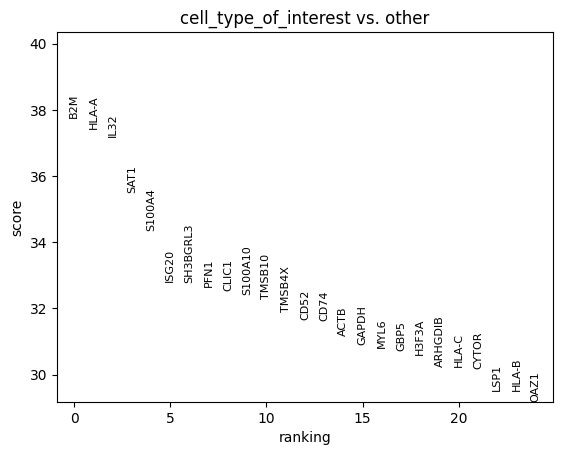

In [35]:
sc.pl.rank_genes_groups(adata_de, groups=[CELL_TYPE_LABEL], n_genes=TOP_N_GENES, sharey=False)

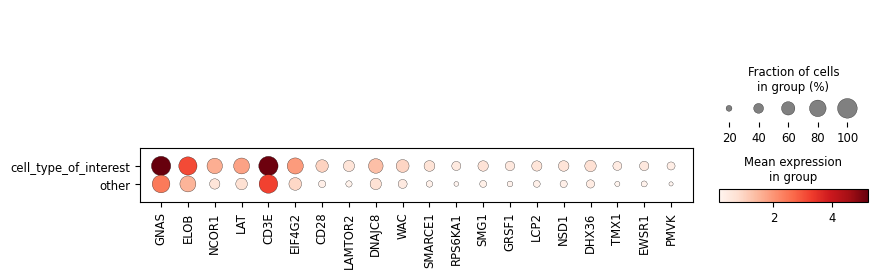

In [46]:
top_gene_names = top_markers["names"].tolist()
dotplot = sc.pl.dotplot(adata_de, top_gene_names, groupby=GROUP_COLUMN, show=False)
plt.savefig('dotplot_high_res.png', dpi=300, bbox_inches='tight')

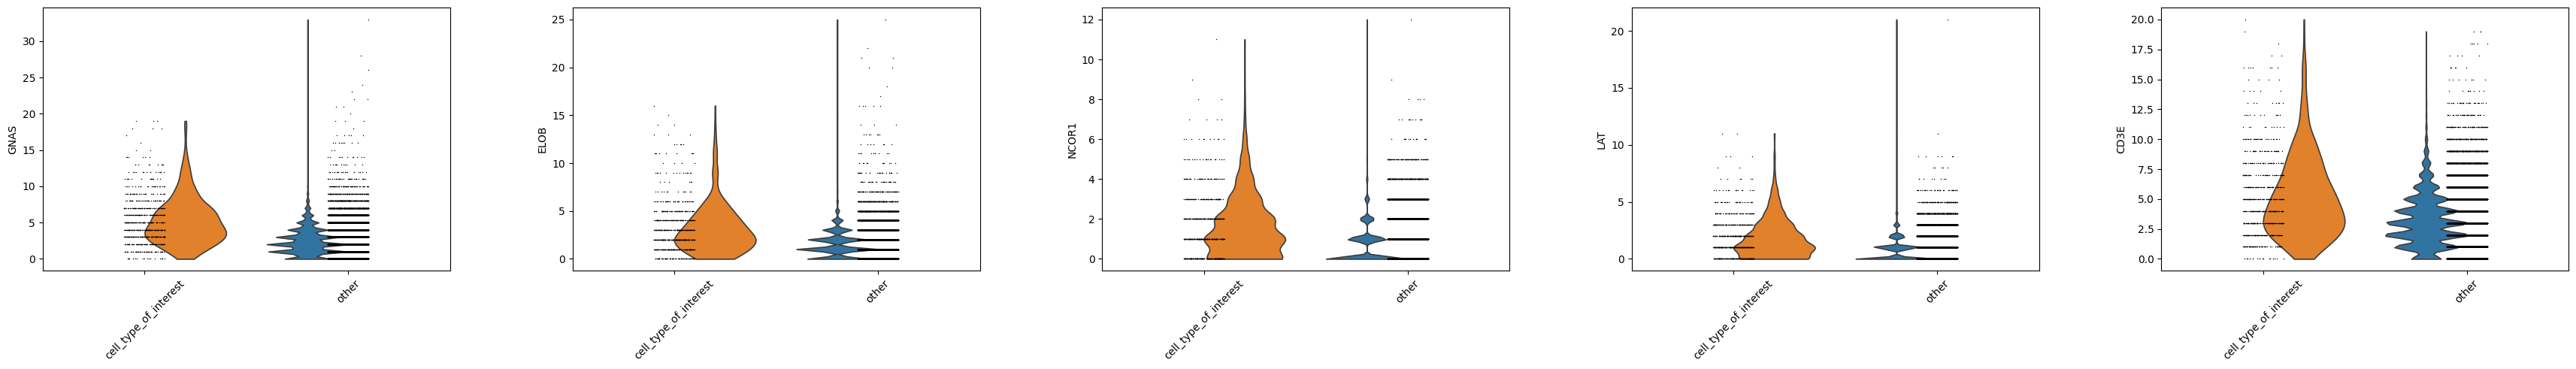

In [44]:
sc.pl.violin(adata_de, top_gene_names[:5], groupby=GROUP_COLUMN, rotation=45)

## Save results

In [14]:
out_csv = OUTPUT_DIR / f"{CELL_TYPE_LABEL}_marker_genes.csv"
markers.to_csv(out_csv, index=False)
print(f"Saved full marker table ({len(markers)} genes) to {out_csv}")

Saved full marker table (33538 genes) to results/cell_type_of_interest_marker_genes.csv


In [ ]:
markers.merge(df_selected_perturbations[
    (df_selected_perturbations["n_total_de_genes"] >= 1500)
    & (~df_selected_perturbations["gene"].isin(("PTMA", "PTPRC")))
    ].rename(columns={"gene": "names"})).head(20)

In [50]:
markers[(markers["pvals_adj"] <= 0.05) & (markers["logfoldchanges"] > 0)].merge(
    df_selected_perturbations.rename(columns={"gene": "names"})).sort_values(
    by="scores", ascending=False)[["names", "scores"]].to_csv(
    "potential_pertubation_targets.csv", index=False)